<a href="https://colab.research.google.com/github/rahullrajesh1/GT3-Telemetry-Analysis-Monza/blob/main/Monza_Telemetry_Analysis_GT3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GT3** **Vehicle** **Telemetry** **Analysis** **and** **hardware** **Diagnosis**

*Objective* : To extract, clean, and visualise 56 channels of raw '.ld' telemetry data from a Porsche 992 GT3 R at Monza


*Outcome* : Successfully built a python pipeline to bypass proprietary software, visualise vehicle dynamics and mathematically diagnose a hardware failure in the throttle potentiometer.



In [ ]:
# Inorder to open the raw file and simply print the First 25 lines of text.
with open('monza-porsche_992_gt3.csv','r',encoding='utf-8',errors='ignore')as file:
  for i in range(25):
    print(f"Row {i}: {file.readline().strip()}")

Row 0: "Format","MoTeC CSV File",,,"Workbook",""
Row 1: "Venue","monza",,,"Worksheet",""
Row 2: "Vehicle","992 GT3 R",,,"Vehicle Desc",""
Row 3: "Driver","",,,"Engine ID",""
Row 4: "Device","ADL"
Row 5: "Comment","",,,"Session",""
Row 6: "Log Date","02-08-2026",,,"Origin Time","0.000","s"
Row 7: "Log Time","20:28:16",,,"Start Time","0.000","s"
Row 8: "Sample Rate","10.000","Hz",,"End Time","1480.795","s"
Row 9: "Duration","1480.795","s",,"Start Distance","0","m"
Row 10: "Range","entire outing",,,"End Distance","68943","m"
Row 11: "Beacon Markers","134.652 248.249 360.628 475.835 591.339 705.473 824.377 1022.270 1136.760 1249.680 1367.180 "
Row 12: 
Row 13: 
Row 14: "Time","LAP_BEACON","G_LAT","ROTY","STEERANGLE","SPEED","THROTTLE","BRAKE","GEAR","G_LON","CLUTCH","RPMS","TC","ABS","SUS_TRAVEL_LF","SUS_TRAVEL_RF","SUS_TRAVEL_LR","SUS_TRAVEL_RR","BRAKE_TEMP_LF","BRAKE_TEMP_RF","BRAKE_TEMP_LR","BRAKE_TEMP_RR","TYRE_PRESS_LF","TYRE_PRESS_RF","TYRE_PRESS_LR","TYRE_PRESS_RR","TYRE_TAIR_LF","T

In [ ]:
import pandas as pd
#To create a specific list of exact row numbers we want to Parse to ignore. Delete's the 1-13 rows and skip's blank rows 15&17
bad_rows = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,15,16,17]
df = pd.read_csv('monza-porsche_992_gt3.csv', skiprows=bad_rows)
df.head()

,Time,LAP_BEACON,G_LAT,ROTY,STEERANGLE,SPEED,THROTTLE,BRAKE,GEAR,G_LON,...,EN_ET,EN_TL,EN_TD,EN_TB,EN_TW,EN_W,EN_Dy,EN_AP,EN_GR,TIME
0,0.0,0,0.0,0.0,0,0.0,0,100,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.1,0,-0.0,0.0,0,0.0,0,100,0,0,...,2,2,2,2,5,1013,2,3,2,0
2,0.2,0,0.0,0.0,0,0.0,0,100,0,0,...,2,2,2,2,5,1013,2,3,2,0
3,0.3,0,0.0,0.0,0,0.0,0,100,0,0,...,2,2,2,2,5,1012,2,2,1,0
4,0.4,0,-0.0,0.0,0,0.0,0,100,0,0,...,2,2,2,2,4,1012,2,1,0,0


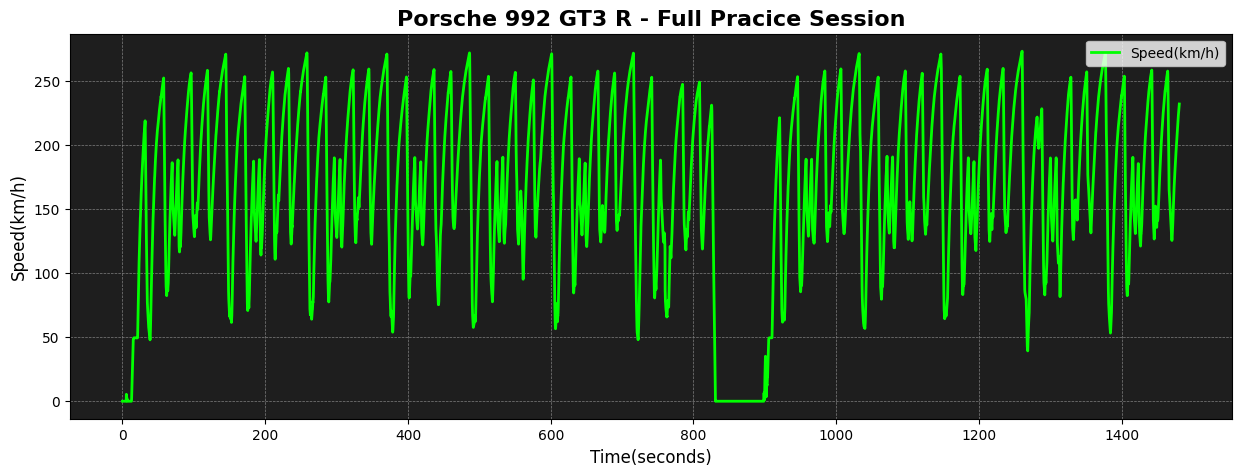

In [ ]:
import matplotlib.pyplot as plt
#To set up the canvas size to look like a Telemetry screen
plt.figure(figsize=(15,5))
#To plot the Speed Trace(Time-> x_axis, Speed-> Y-axis)
plt.plot(df['Time'], df['SPEED'], color='lime', linewidth=2,label='Speed(km/h)')
#Label and Title and grid colour
plt.title('Porsche 992 GT3 R - Full Pracice Session', fontsize=16, fontweight='bold')
plt.xlabel('Time(seconds)', fontsize=12)
plt.ylabel('Speed(km/h)', fontsize=12)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_facecolor('#1e1e1e')
plt.legend(loc='upper right')
#Display
plt.show()

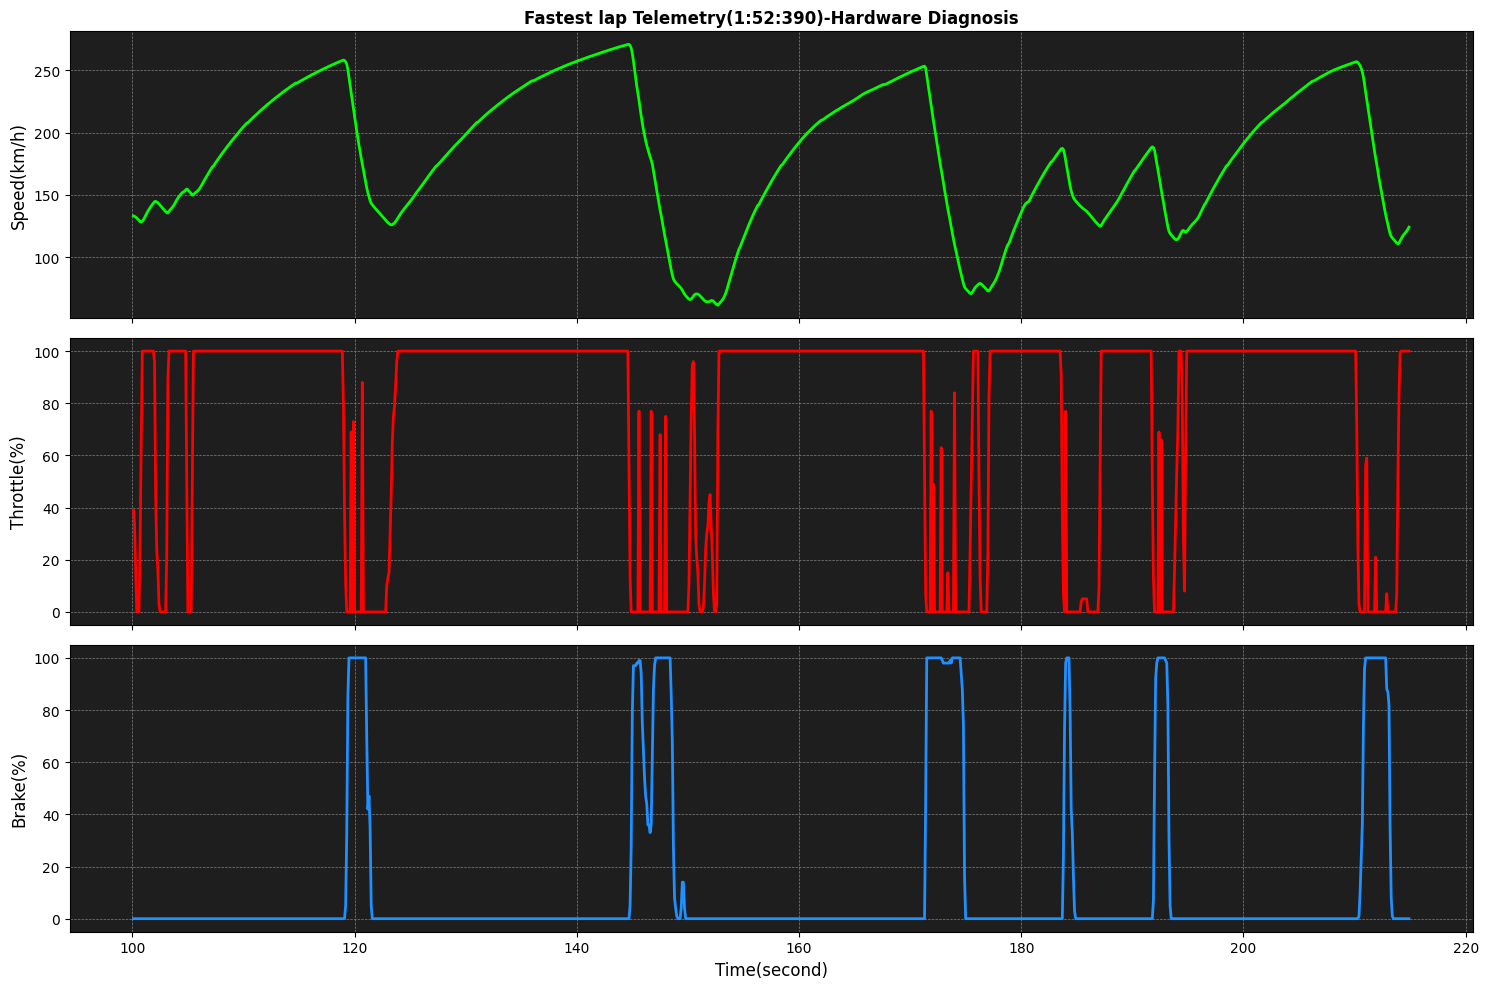

In [ ]:
import matplotlib.pyplot as plt
#Slicing the data for a 115 second window(1lap), 100s-215s window frame from the session
lap_df = df[(df['Time']>100)&(df['Time']<215)]
#Creating subplot, 'sharex=True' locks the time axis to vertically align perfectly
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15,10), sharex=True)

#Speed Graph
ax1.plot(lap_df['Time'], lap_df['SPEED'], color='lime', linewidth=2)
ax1.set_title('Fastest lap Telemetry(1:52:390)-Hardware Diagnosis', fontsize=12, fontweight='bold')
ax1.set_ylabel('Speed(km/h)', fontsize=12)
ax1.grid(color='gray', linestyle='--', linewidth=0.5)
ax1.set_facecolor('#1e1e1e')

#Throtte Graph
ax2.plot(lap_df['Time'], lap_df['THROTTLE'], color='red', linewidth=2)
ax2.set_ylabel('Throttle(%)', fontsize=12)
ax2.grid(color='gray', linestyle='--', linewidth=0.5)
ax2.set_facecolor('#1e1e1e')

#Bottom Graph
ax3.plot(lap_df['Time'],lap_df['BRAKE'], color='dodgerblue',linewidth=2)
ax3.set_ylabel('Brake(%)', fontsize=12)
ax3.set_xlabel('Time(second)', fontsize=12)
ax3.grid(color='gray', linestyle='--', linewidth=0.5)
ax3.set_facecolor('#1e1e1e')

#Display
plt.tight_layout()
plt.show()
